# Model building

Use `liesel.model` to describe a statistical model, inspect its dependencies,
and evaluate its log density. A model also lets you calculate predictions and
simulate new responses. Constructing it does not fit its parameters.

This small regression has a normal prior on its coefficients and a fixed
response standard deviation:

In [1]:
import jax.numpy as jnp
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl

x = lsl.Var.new_obs(jnp.array([-1.0, 0.0, 1.0]), name="x")

beta = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=2.5),
    name="beta",
)

mu = lsl.Var.new_calc(
    lambda x, b: b[0] + b[1] * x,
    x,
    beta,
    name="mu",
)

y = lsl.Var.new_obs(
    jnp.array([-0.8, 1.1, 2.9]),
    dist=lsl.Dist(tfd.Normal, loc=mu, scale=1.0),
    name="y",
)
model = lsl.Model(y)

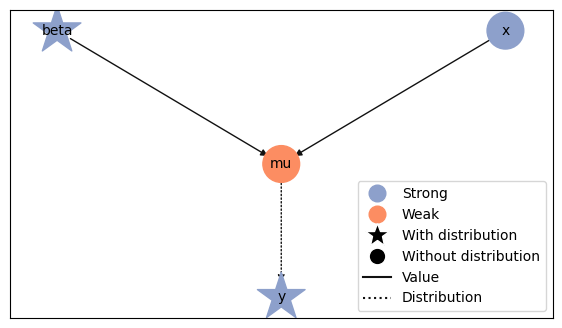

In [2]:
model.plot(width=7, height=4)

In [3]:
round(float(model.log_prob), 3)

-11.557

`Model(y)` collects the response and its inputs. The value is the
log likelihood plus the log prior at `beta = [0, 0]`; these are starting
values, not estimates. Pass variables into calculations and distributions so
Liesel can track their dependencies.

## Start here

```{toctree}
:maxdepth: 1

Overview <self>
Build your first model <tutorials/notebooks/11-model-building>
Fit and predict <tutorials/notebooks/12-model-predictions>
```

## Common tasks

```{toctree}
:maxdepth: 1

model-inspection
model-transformations
model-modification
model-composition
model-state
model-prediction
model-simulation
model-distributions
```

For point estimates, continue with {doc}`optimization`. For posterior sampling,
see {doc}`tutorials/md/01c-transform`. Arguments and defaults live in the
{ref}`model-api`.